# 🌾 Pakistan Crop Recommendation — ML Model

**Goal:** Recommend the best crop to grow based on soil and climate conditions.

**Dataset:** 1,000 samples · 10 Pakistani crops · 7 features (N, P, K, temperature, humidity, pH, rainfall)

**What this notebook covers:**
1. Exploratory Data Analysis (EDA)
2. Comparing multiple ML models
3. Training a Neural Network with best practices
4. Evaluating with cross-validation & confusion matrix
5. Making predictions on new data

> 📦 Dataset: [Pakistan Crop Recommendation on Kaggle](https://www.kaggle.com/datasets/abdulqadirds/crop-recommendation-dataset)


## 1. Setup, Imports & Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, os, json

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)

import tensorflow as tf
from tensorflow import keras

warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'  
tf.get_logger().setLevel('ERROR')          

np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow version : {tf.__version__}")
print(f"Scikit-learn ready : ✓")

2026-05-21 15:30:56.583621: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779377456.990919      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779377457.107281      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779377458.098021      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779377458.098061      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779377458.098064      23 computation_placer.cc:177] computation placer alr

TensorFlow version : 2.19.0
Scikit-learn ready : ✓


## 2. Load the Dataset

In [2]:
df = pd.read_csv('/kaggle/input/datasets/abdulqadirds/crop-recommendation-dataset/pakistan_crop_recommendation.csv')

print(f"Dataset shape  : {df.shape[0]} rows × {df.shape[1]} columns")
print(f"Crops          : {df['label'].nunique()} unique classes")
print(f"Missing values : {df.isnull().sum().sum()} total")
print()
df.head()

Dataset shape  : 1000 rows × 8 columns
Crops          : 10 unique classes
Missing values : 0 total



,N,P,K,temperature,humidity,ph,rainfall,label
0,101.0,58.0,18.0,25.668914,81.381033,6.652144,78.595958,Kapas
1,101.3,31.2,70.0,26.540000,58.200000,7.190000,1161.770000,Ganna
2,92.6,37.1,76.2,31.910000,70.150000,7.300000,1171.370000,Ganna
3,114.7,55.9,35.9,16.440000,39.090000,7.430000,255.060000,Gandum
4,2.0,75.0,22.0,23.892719,61.787794,6.658605,52.557301,Masoor


## 3. Exploratory Data Analysis (EDA)

### Basic Statistics

In [3]:
# Summary statistics for all features
df.describe().round(2)

,N,P,K,temperature,humidity,ph,rainfall
count,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00
mean,72.51,55.40,41.81,22.40,61.92,6.72,296.90
std,35.33,12.53,23.63,5.52,20.00,0.64,351.69
min,0.00,30.00,15.00,10.07,14.26,5.01,35.03
25%,40.00,45.00,21.00,18.52,51.64,6.28,69.05
50%,79.00,55.25,37.40,22.04,64.51,6.66,146.16
75%,97.60,65.00,60.12,26.03,79.99,7.14,377.92
max,140.00,80.00,99.90,37.79,90.00,8.87,1497.78


### Class Distribution

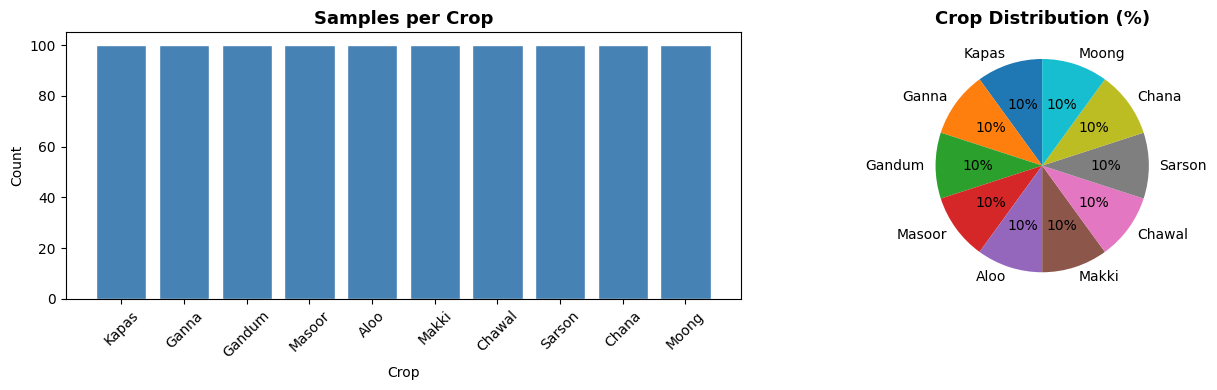

✓ Dataset is perfectly balanced — 100 samples per crop


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Bar chart
crop_counts = df['label'].value_counts()
axes[0].bar(crop_counts.index, crop_counts.values, color='steelblue', edgecolor='white')
axes[0].set_title('Samples per Crop', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Crop')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

# Pie chart
axes[1].pie(crop_counts.values, labels=crop_counts.index,
            autopct='%1.0f%%', startangle=90)
axes[1].set_title('Crop Distribution (%)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()
print("✓ Dataset is perfectly balanced — 100 samples per crop")

### Feature Distributions by Crop

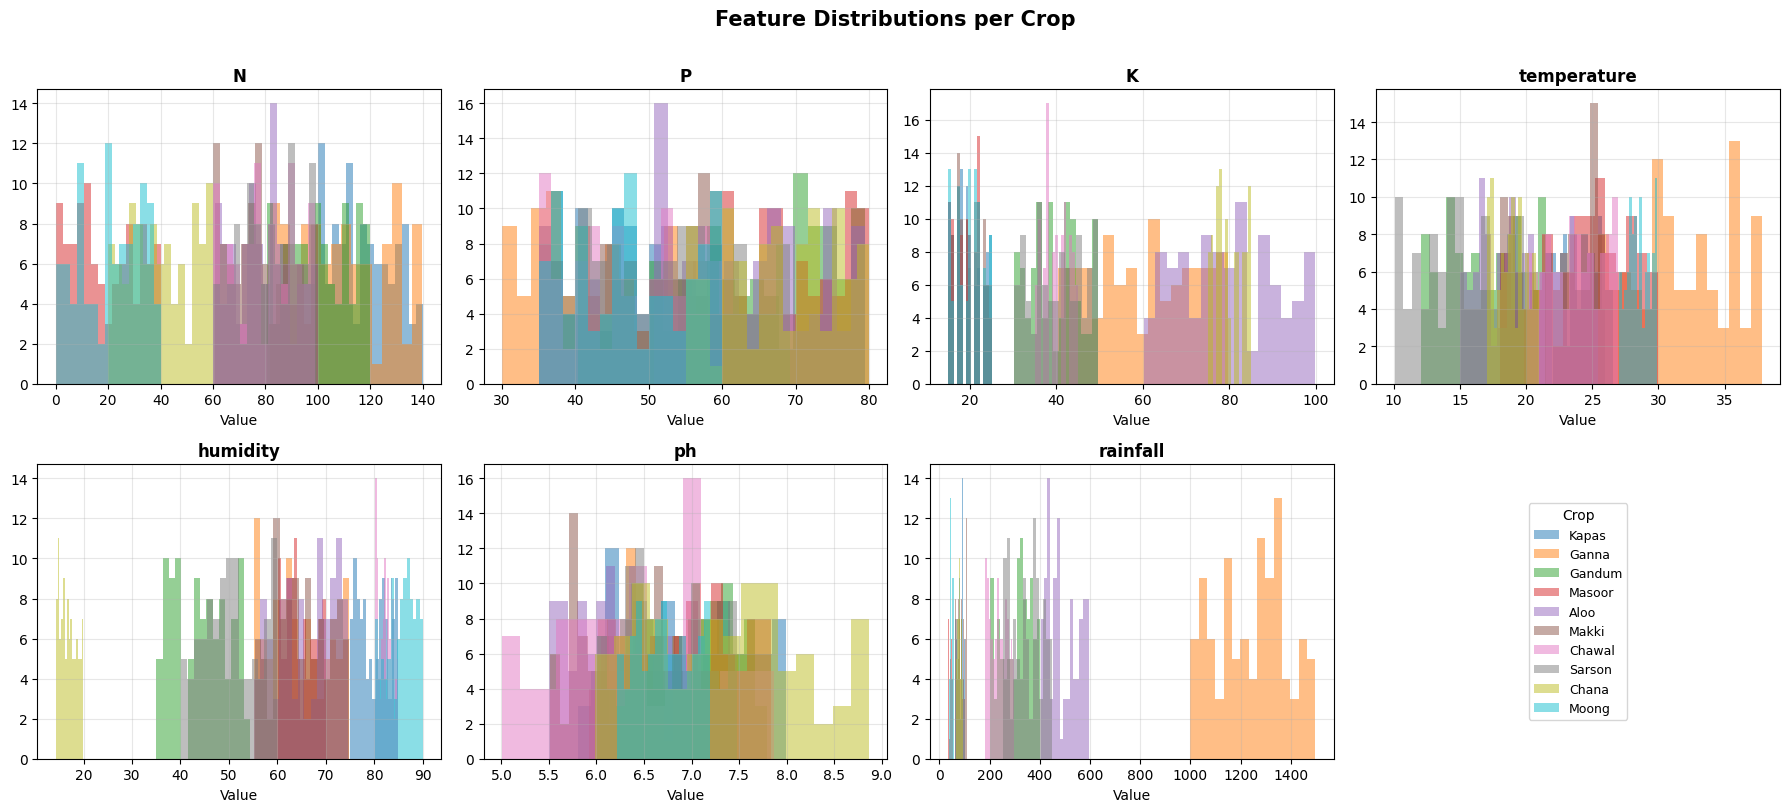

In [5]:
features = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, feat in enumerate(features):
    for crop in df['label'].unique():
        vals = df[df['label'] == crop][feat]
        axes[i].hist(vals, bins=15, alpha=0.5, label=crop)
    axes[i].set_title(feat, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].grid(True, alpha=0.3)

# Use last subplot for legend
axes[-1].axis('off')
handles, labels = axes[0].get_legend_handles_labels()
axes[-1].legend(handles, labels, title='Crop', loc='center', fontsize=9)

fig.suptitle('Feature Distributions per Crop', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### Correlation Heatmap

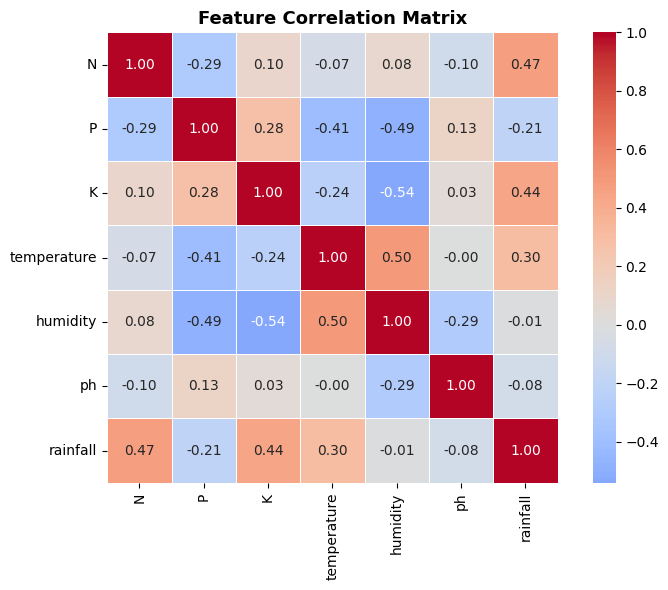

Top 3 correlated feature pairs:
K            humidity    0.539649
temperature  humidity    0.499439
P            humidity    0.486820


In [6]:
corr = df[features].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5)
plt.title('Feature Correlation Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Print the strongest correlations
corr_pairs = corr.abs().unstack().sort_values(ascending=False)
corr_pairs = corr_pairs[corr_pairs < 1].drop_duplicates()
print("Top 3 correlated feature pairs:")
print(corr_pairs.head(3).to_string())

## 4. Preprocessing, Encode Labels & Scale Features

In [7]:
# Encode crop names to numbers (0–9)
le = LabelEncoder()
y = le.fit_transform(df['label'])
X = df[features].values

print("Label mapping:")
for idx, name in enumerate(le.classes_):
    print(f"  {idx} → {name}")

# Save label map for inference
label_map = {int(i): str(name) for i, name in enumerate(le.classes_)}
with open('label_map.json', 'w') as f:
    json.dump(label_map, f)
print("\n✓ label_map.json saved")

Label mapping:
  0 → Aloo
  1 → Chana
  2 → Chawal
  3 → Gandum
  4 → Ganna
  5 → Kapas
  6 → Makki
  7 → Masoor
  8 → Moong
  9 → Sarson

✓ label_map.json saved


In [8]:
# Scale features to mean=0, std=1 (improves neural network training)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Save scaler parameters for inference
scaler_params = {
    'mean': scaler.mean_.tolist(),
    'scale': scaler.scale_.tolist(),
    'feature_names': features
}
with open('scaler_params.json', 'w') as f:
    json.dump(scaler_params, f)

# Train/Test split — 80% train, 20% test, stratified
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training samples : {X_train.shape[0]}")
print(f"Test samples     : {X_test.shape[0]}")
print(f"Features         : {X_train.shape[1]}")
print("\n✓ scaler_params.json saved")

Training samples : 800
Test samples     : 200
Features         : 7

✓ scaler_params.json saved


## 5. Model Comparison

Before training a neural network, let's compare classic ML models.  
We use **5-fold cross-validation** for reliable accuracy estimates.

In [9]:
# Define candidate models
models = {
    'Random Forest'       : RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting'   : GradientBoostingClassifier(n_estimators=100, random_state=42),
    'Support Vector (SVM)': SVC(kernel='rbf', C=1.0, random_state=42),
    'K-Nearest Neighbors' : KNeighborsClassifier(n_neighbors=5),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}

print(f"{'Model':<25} {'Mean Acc':>9} {'Std':>6}")
print("-" * 43)

for name, clf in models.items():
    scores = cross_val_score(clf, X_scaled, y, cv=cv, scoring='accuracy')
    results[name] = scores
    print(f"{name:<25} {scores.mean()*100:>8.2f}%  ±{scores.std()*100:.2f}%")

Model                      Mean Acc    Std
-------------------------------------------
Random Forest                98.70%  ±0.60%
Gradient Boosting            98.10%  ±0.86%
Support Vector (SVM)         97.50%  ±0.55%
K-Nearest Neighbors          96.40%  ±0.73%


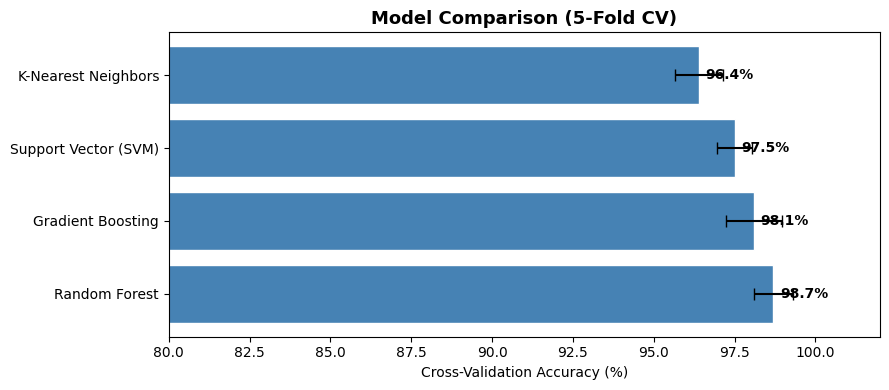

In [10]:
# Bar chart comparing model accuracies
means = [results[m].mean()*100 for m in results]
stds  = [results[m].std()*100  for m in results]
names = list(results.keys())

plt.figure(figsize=(9, 4))
bars = plt.barh(names, means, xerr=stds, color='steelblue',
                edgecolor='white', capsize=4)
plt.xlabel('Cross-Validation Accuracy (%)')
plt.title('Model Comparison (5-Fold CV)', fontsize=13, fontweight='bold')
plt.xlim(80, 102)
for bar, val in zip(bars, means):
    plt.text(val + 0.2, bar.get_y() + bar.get_height()/2,
             f'{val:.1f}%', va='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

### Feature Importance (Random Forest)

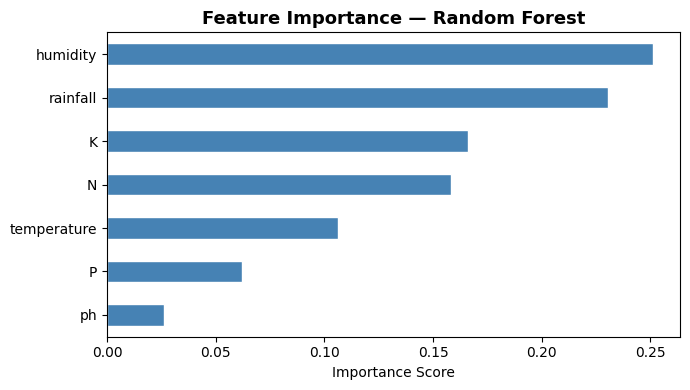

Most important feature: humidity
Least important feature: ph


In [11]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

importances = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=True)

plt.figure(figsize=(7, 4))
importances.plot(kind='barh', color='steelblue', edgecolor='white')
plt.title('Feature Importance — Random Forest', fontsize=13, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print("Most important feature:", importances.idxmax())
print("Least important feature:", importances.idxmin())

## 6. Neural Network

Now we train a neural network with:
- **Batch Normalization** stabilizes training
- **Dropout** reduces overfitting  
- **Early Stopping** stops when validation stops improving
- **ReduceLROnPlateau** lowers learning rate when stuck

In [12]:
num_classes = len(le.classes_)

# One-hot encode labels for the neural network
y_train_oh = keras.utils.to_categorical(y_train, num_classes)
y_test_oh  = keras.utils.to_categorical(y_test,  num_classes)

model = keras.Sequential([
    keras.layers.Input(shape=(7,)),

    keras.layers.Dense(128, activation='relu'),
    keras.layers.BatchNormalization(),
    keras.layers.Dropout(0.3),

    keras.layers.Dense(64, activation='relu'),
    keras.layers.BatchNormalization(),
    keras.layers.Dropout(0.2),

    keras.layers.Dense(32, activation='relu'),

    keras.layers.Dense(num_classes, activation='softmax')
], name='Pakistan_Crop_Recommender')

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

I0000 00:00:1779377516.311293      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1779377516.317273      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "Pakistan_Crop_Recommender"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,458 (48.66 KB)

 Trainable params: 12,074 (47.16 KB)

 Non-trainable params: 384 (1.50 KB)

In [13]:
callbacks = [
    keras.callbacks.EarlyStopping(patience=15, restore_best_weights=True, verbose=0),
    keras.callbacks.ReduceLROnPlateau(factor=0.3, patience=7, min_lr=1e-6, verbose=0)
]

history = model.fit(
    X_train, y_train_oh,
    epochs=150,
    batch_size=32,
    validation_split=0.15,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/150


I0000 00:00:1779377520.087415      72 service.cc:152] XLA service 0x7809ec00ee60 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1779377520.087447      72 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1779377520.087451      72 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1779377520.611018      72 cuda_dnn.cc:529] Loaded cuDNN version 91002


21/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.1838 - loss: 2.3119 

I0000 00:00:1779377522.926648      72 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


22/22 ━━━━━━━━━━━━━━━━━━━━ 8s 159ms/step - accuracy: 0.1933 - loss: 2.2824 - val_accuracy: 0.7000 - val_loss: 1.9242 - learning_rate: 0.0010
Epoch 2/150
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6715 - loss: 1.1119 - val_accuracy: 0.7583 - val_loss: 1.6557 - learning_rate: 0.0010
Epoch 3/150
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7995 - loss: 0.7253 - val_accuracy: 0.7917 - val_loss: 1.4258 - learning_rate: 0.0010
Epoch 4/150
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8576 - loss: 0.5314 - val_accuracy: 0.8750 - val_loss: 1.2137 - learning_rate: 0.0010
Epoch 5/150
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9186 - loss: 0.3843 - val_accuracy: 0.9250 - val_loss: 1.0030 - learning_rate: 0.0010
Epoch 6/150
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9282 - loss: 0.3134 - val_accuracy: 0.9250 - val_loss: 0.8038 - learning_rate: 0.0010
Epoch 7/150
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9369 - loss: 0.2502 - val_accuracy: 0.9

## 7. Training Curves

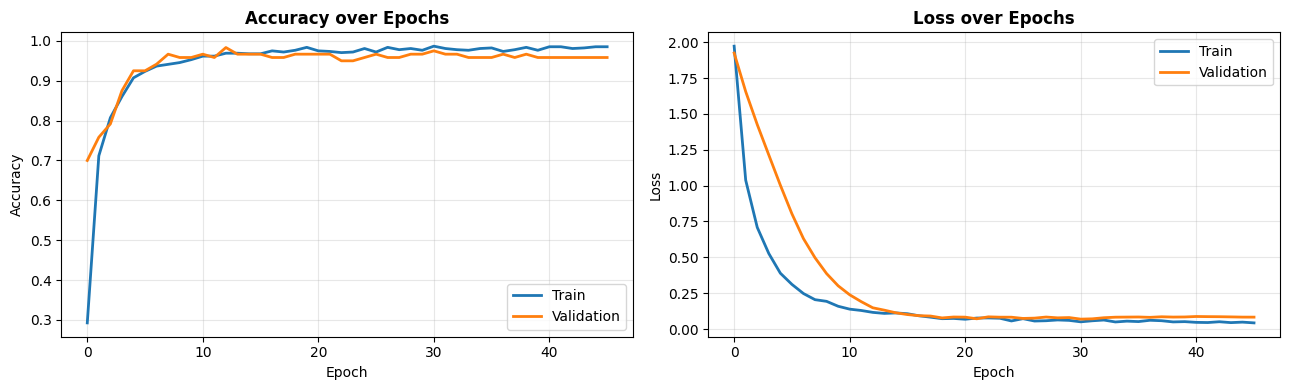

✓ training_curves.png saved


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Accuracy
axes[0].plot(history.history['accuracy'],     label='Train', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Validation', linewidth=2)
axes[0].set_title('Accuracy over Epochs', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Loss
axes[1].plot(history.history['loss'],     label='Train', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Validation', linewidth=2)
axes[1].set_title('Loss over Epochs', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ training_curves.png saved")

## 8. Model Evaluation

In [15]:
loss, acc = model.evaluate(X_test, y_test_oh, verbose=0)
y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)

print(f"{'='*40}")
print(f"  Test Accuracy : {acc*100:.2f}%")
print(f"  Test Loss     : {loss:.4f}")
print(f"{'='*40}")

print("\nDetailed Classification Report:")
class_names = list(le.classes_)
print(classification_report(y_test, y_pred, target_names=class_names))

  Test Accuracy : 98.00%
  Test Loss     : 0.0811

Detailed Classification Report:
              precision    recall  f1-score   support

        Aloo       1.00      1.00      1.00        20
       Chana       1.00      1.00      1.00        20
      Chawal       1.00      1.00      1.00        20
      Gandum       0.90      0.90      0.90        20
       Ganna       1.00      1.00      1.00        20
       Kapas       1.00      1.00      1.00        20
       Makki       1.00      1.00      1.00        20
      Masoor       1.00      1.00      1.00        20
       Moong       1.00      1.00      1.00        20
      Sarson       0.90      0.90      0.90        20

    accuracy                           0.98       200
   macro avg       0.98      0.98      0.98       200
weighted avg       0.98      0.98      0.98       200



<Figure size 900x700 with 0 Axes>

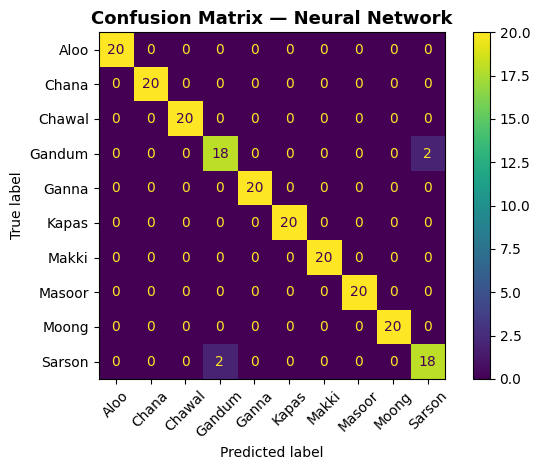

✓ confusion_matrix.png saved


In [16]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(9, 7))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(colorbar=True, xticks_rotation=45)
plt.title('Confusion Matrix — Neural Network', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ confusion_matrix.png saved")

### All Models — Final Accuracy Summary

In [17]:
# Evaluate all classic models on the test set
print(f"{'Model':<25} {'CV Accuracy':>12} {'Test Accuracy':>14}")
print("-" * 55)

for name, clf in models.items():
    clf.fit(X_train, y_train)
    test_acc = accuracy_score(y_test, clf.predict(X_test))
    cv_acc   = results[name].mean()
    print(f"{name:<25} {cv_acc*100:>11.2f}%  {test_acc*100:>13.2f}%")

nn_test = accuracy_score(y_test, y_pred)
print(f"{'Neural Network':<25} {'(see above)':>12}  {nn_test*100:>13.2f}%")

Model                      CV Accuracy  Test Accuracy
-------------------------------------------------------
Random Forest                   98.70%          97.50%
Gradient Boosting               98.10%          97.00%
Support Vector (SVM)            97.50%          96.00%
K-Nearest Neighbors             96.40%          96.00%
Neural Network             (see above)          98.00%


## 9. Export Model (TFLite for Mobile/Edge)

In [18]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()

with open('crop_model.tflite', 'wb') as f:
    f.write(tflite_model)

print(f"✓ crop_model.tflite saved ({len(tflite_model)/1024:.1f} KB)")
print(f"✓ label_map.json saved")
print(f"✓ scaler_params.json saved")

Saved artifact at '/tmp/tmpauao08is'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 7), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  131987646341264: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131987641025552: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131987641027472: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131987641027856: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131987641027280: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131987641027088: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131987646348944: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131987641028240: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131987641028624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131987641028816: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131987641027664: Tensor

W0000 00:00:1779377540.545025      23 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1779377540.545077      23 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
I0000 00:00:1779377540.556204      23 mlir_graph_optimization_pass.cc:425] MLIR V1 optimization pass is not enabled


## 10. Predict for New Input

Use this function to get crop recommendations for any soil/climate values.

In [19]:
def recommend_crop(N, P, K, temperature, humidity, ph, rainfall):
    """
    Returns the recommended crop given soil and climate inputs.

    Parameters:
        N, P, K        : Nitrogen, Phosphorus, Potassium (kg/ha)
        temperature    : °C
        humidity       : % relative humidity
        ph             : soil pH
        rainfall       : mm per year

    Returns:
        crop name (str), confidence (%)
    """
    inp = np.array([[N, P, K, temperature, humidity, ph, rainfall]])
    inp_scaled = scaler.transform(inp)
    probs = model.predict(inp_scaled, verbose=0)[0]
    idx   = np.argmax(probs)
    return le.classes_[idx], round(probs[idx] * 100, 2)


# ── Example predictions ───────────────────────────────────────────────────────
examples = [
    dict(N=101, P=58, K=18, temperature=25.7, humidity=81.4, ph=6.65, rainfall=78.6),   # Kapas
    dict(N=3,   P=75, K=22, temperature=23.9, humidity=61.8, ph=6.66, rainfall=52.6),   # Masoor
    dict(N=100, P=60, K=40, temperature=27.0, humidity=85.0, ph=6.50, rainfall=200.0),  # custom
]

print(f"{'N':>4} {'P':>4} {'K':>4} {'Temp':>6} {'Hum':>6} {'pH':>5} {'Rain':>7}   →  {'Crop':<12} {'Confidence':>12}")
print("-" * 75)
for ex in examples:
    crop, conf = recommend_crop(**ex)
    print(f"{ex['N']:>4} {ex['P']:>4} {ex['K']:>4} {ex['temperature']:>6.1f} "
          f"{ex['humidity']:>6.1f} {ex['ph']:>5.2f} {ex['rainfall']:>7.1f}   →  {crop:<12} {conf:>10.1f}%")

   N    P    K   Temp    Hum    pH    Rain   →  Crop           Confidence
---------------------------------------------------------------------------
 101   58   18   25.7   81.4  6.65    78.6   →  Kapas              96.3%
   3   75   22   23.9   61.8  6.66    52.6   →  Masoor            100.0%
 100   60   40   27.0   85.0  6.50   200.0   →  Chawal             99.8%


## Summary

| Step | What we did |
|------|-------------|
| EDA | Visualized feature distributions, class balance, and correlations |
| Model Comparison | Compared Random Forest, Gradient Boosting, SVM, KNN via 5-fold CV |
| Feature Importance | Identified which soil/climate features matter most |
| Neural Network | Trained a 3-layer NN with BatchNorm, Dropout, Early Stopping |
| Evaluation | Classification report + confusion matrix on held-out test set |
| Export | Saved TFLite model, label map, and scaler for deployment |

### Output Files
- `crop_model.tflite` lightweight model for mobile/edge deployment  
- `label_map.json` index → crop name mapping  
- `scaler_params.json` mean/std values to normalize new inputs  
- `training_curves.png` accuracy & loss plots  
- `confusion_matrix.png` per-class prediction breakdown  

---
*If you found this notebook useful, please ⭐ upvote on Kaggle and share on LinkedIn!*
